In [28]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
df = pd.read_csv('placement.csv')

df.shape



(60, 8)

In [30]:
df.head()

,student_id,cgpa,attendance,iq,internships,branch,placement,package_lpa
0,STU001,8.6,92.0,128.0,2.0,CSE,Placed,8.5
1,STU002,7.4,78.0,105.0,1.0,IT,Placed,5.2
2,STU003,6.8,71.0,98.0,0.0,ECE,Not Placed,0.0
3,STU004,9.1,95.0,135.0,3.0,CSE,Placed,12.0
4,STU005,7.9,84.0,112.0,1.0,IT,Placed,6.4


Text(0, 0.5, 'Package(in lpa)')

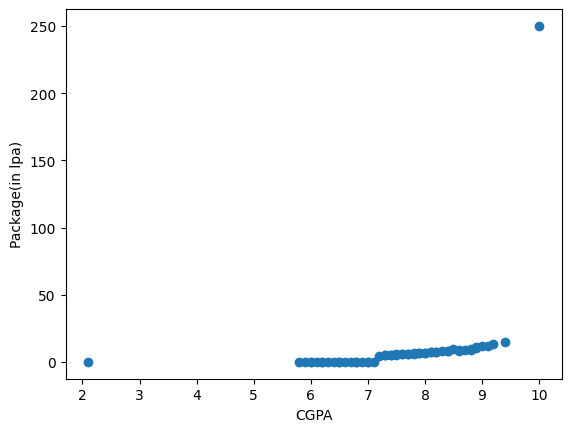

In [31]:
plt.scatter(df['cgpa'],df['package_lpa'])
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [36]:
X = df.iloc[:,1:5]
y = df.iloc[:,-1]

In [45]:

X['cgpa']=X['cgpa'].fillna(X['cgpa'].mean())
X['internships']=X['internships'].fillna(X['internships'].mean())
X['iq']=X['iq'].fillna(X['iq'].mean())
X['attendance']=X['attendance'].fillna(X['attendance'].mean())
X

,cgpa,attendance,iq,internships
0,8.600000,92.0,128.000000,2.000000
1,7.400000,78.0,105.000000,1.000000
2,6.800000,71.0,98.000000,0.000000
3,9.100000,95.0,135.000000,3.000000
4,7.900000,84.0,112.000000,1.000000
5,6.200000,65.0,89.000000,0.000000
6,8.200000,88.0,119.000000,2.000000
7,7.100000,76.0,101.000000,0.000000
8,8.800000,91.0,130.000000,2.000000
9,6.900000,73.0,95.000000,1.000000


In [53]:
y=y.fillna(y.mean())
y

0       8.500000
1       5.200000
2       0.000000
3      12.000000
4       6.400000
5       0.000000
6       7.100000
7       0.000000
8       9.300000
9       0.000000
10      5.800000
11      7.800000
12      0.000000
13     14.500000
14      4.900000
15      6.700000
16      0.000000
17      7.000000
18      6.100000
19      0.000000
20     10.800000
21      0.000000
22      7.400000
23      0.000000
24      5.500000
25      8.900000
26      0.000000
27      6.000000
28     11.500000
29      0.000000
30      7.900000
31      4.700000
32      0.000000
33      9.700000
34      6.800000
35      0.000000
36      6.900000
37      5.900000
38      0.000000
39     13.200000
40      5.100000
41      0.000000
42      8.200000
43      6.300000
44      0.000000
45      9.000000
46      0.000000
47      7.600000
48      5.000000
49      0.000000
50    250.000000
51      0.000000
52      8.000000
53      6.200000
54      5.700000
55      9.164407
56     10.200000
57      5.600000
58      0.0000

In [54]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[36.39,-4.33,-0.21,22.5 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['cgpa','attendance','iq','internships']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,75.74
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [55]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
y_pred = lr.predict(X_test)
y_test.values


array([ 6.9       ,  8.5       ,  7.6       ,  9.16440678,  0.        ,
        0.        ,  0.        , 11.5       ,  0.        ,  0.        ,
        5.2       ,  7.9       ])

In [57]:
print("MAE",mean_absolute_error(y_test,y_pred))

print("MSE",mean_squared_error(y_test,y_pred))

print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred)))

print("MSE",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)


MAE 9.271228356288946
MSE 121.29211525390521
RMSE 11.013269961909824
MSE -5.776415657519506


In [58]:
# Adjusted R2 score
X_test.shape
adjr2=1 - ((1-r2)*(40-1)/(40-1-1))
print(adjr2)

-5.9547423853489665
